# Ch12. 포트폴리오 백테스팅

- 백테스팅: 최고의 전략, or 적어도 수익성이 높은 전략을 찾기위함 탐구

[12.1] 프로토콜 세팅
- 데이터셋: 시간 $t=1,..,T$, 자산 $n=1,...,N$, 특성 $k=1,...,K$의 3차원 구조
- 표본 외 기간 / 초기 버퍼 기간으로 나눔
- 버퍼 기간: 첫 번째 포트폴리오 구축을 위해 모델을 훈련하고자 필요함
$\\ \rarr$ 크기: (1) 고정: 훈련 샘플 롤링 (2) 확장: 가능한 모든 데이터에 기반 ~ 시간에 따라 데이터 크기 커짐
- 디자인 선택: (1) 리밸런싱 주기 (2) 레이블 계산 시계열
- $\Delta_h$: 두 리밸런싱 날짜 사이의 보유기간
- $\Delta_s$: 원하는 훈련 샘플의 크기
- $\Delta_l$: 레이블이 계산되는 기간
$\\ \rarr$ 훈련 샘플의 총 길이: $\Delta_s+\Delta_l$

[12.2] 신호를 포트폴리오 가중치로 변환하기
1. 선택: 모든 자산에 투자할 필요 x
- the most heuristic method: 가장 유리한 예측 자산 선택 & 나머지 버리기 ~ 정렬된 포트폴리오(사분위수에 따른 수익성)
- 1번 포트폴리오와 Q번 포트폴리오의 차이가 크면 신호는 가치가 있음
2. 가중치 부여: ex. 평균 분산 최적화
$\\ \underset{\textbf{w}}{\text{min}} \ \frac{\lambda}{2} \textbf{w}'\boldsymbol{\Sigma}\textbf{w}-\textbf{w}'\boldsymbol{\mu} , \quad \text{s.t.} \quad \begin{array}{ll} \textbf{w}'\textbf{1}=1, \\ (\textbf{w}-\textbf{w}_-)'\boldsymbol{\Lambda}(\textbf{w}-\textbf{w}_-) \le \delta_R,\\
\textbf{w}'\textbf{w} \le \delta_D,
\end{array}$
- (i) 예산 제약 조건(가중치 합=1)
- (ii) 거래 비용에 불이익을 주는 대각행렬 $\boldsymbol{\Lambda}$를 통해 현재 가중치 $\textbf{w}_-$와 비교 ~ 가중치 변화에 불이익
- $\delta_R$이 감소하면 가중치가 너무 많이 벗어날 수 없음 -> 회전률 감소
- (iii) 포트폴리오의 허핀달-허쉬만 지수 통해 분산 투자 강제 
- $\delta_D$가 작을수록 포트폴리오의 분산 투자 효과 증가
$\\$ <라그랑지안 계산>
$\\ L(\textbf{w})= \frac{\lambda}{2} \textbf{w}'\boldsymbol{\Sigma}\textbf{w}-\textbf{w}'\boldsymbol{\mu}-\eta (\textbf{w}'\textbf{1}_N-1)+\kappa_R ( (\textbf{w}-\textbf{w}_-)'\boldsymbol{\Lambda}(\textbf{w}-\textbf{w}_-) - \delta_R)+\kappa_D(\textbf{w}'\textbf{w}-\delta_D)$
$\\ \textbf{w}^*_\kappa=  (\lambda \boldsymbol{\Sigma}+2\kappa_R \boldsymbol{\Lambda} +2\kappa_D\textbf{I}_N)^{-1} \left(\boldsymbol{\mu} + \eta_{\lambda,\kappa_R,\kappa_D} \textbf{1}_N+2\kappa_R \boldsymbol{\Lambda}\textbf{w}_-\right)$
$\\ \eta_{\lambda,\kappa_R,\kappa_D}=\frac{1- \textbf{1}_N'(\lambda\boldsymbol{\Sigma}+2\kappa_R \boldsymbol{\Lambda}+2\kappa_D\textbf{I}_N)^{-1}(\boldsymbol{\mu}+2\kappa_R\boldsymbol{\Lambda}\textbf{w}_-)}{\textbf{1}'_N(\lambda \boldsymbol{\Sigma}+2\kappa_R \boldsymbol{\Lambda}+2\kappa_D\textbf{I}_N)^{-1}\textbf{1}_N}$
$\\ \rarr$ 세 가지 튜닝 매개 변수:
- $\lambda$: 크면 수익 극대화보다는 위험 감소에 더 중점(위험이 더 예측하기 쉽다는 점에서 이는 좋은 아이디어인 경우 많음)
- $\kappa_R$: 크면 거래 비용의 중요도 높아짐, if infinit: 이전 가중치와 같아짐
- $\kappa_D$: 크면 포트폴리오의 분산 투자 효과가 더 커짐, if infinit: 동일 가중이 됨
- if $\kappa_{R,D}=0$: 최대 샤프 비율 포트폴리오 & 최소 분산 포트폴리오 혼합한 고전적인 평균-분산 가중치로 포트폴리오 회귀

[12.3] 성과 지표
- 포트폴리오 수익률: 백테스트의 궁극적 척도
- 필수 요소: 벤치마크
- 동일 가중 배분: consequently 이기기 어려운 벤치마크 ~ 불확실성과 모호성 or 추정 위험이 높을 때 최적이 됨

[12.3.2] 순수한 성과 및 위험 지표
- (i) 가장 간단한 수익률 지표: 평균 수익률
- 산술평균
$\bar{r}_P=\mu_P=\mathbb{E}[r^P]\approx \frac{1}{T}\sum_{t=1}^T r_t^P, \quad \bar{r}_B=\mu_B=\mathbb{E}[r^B]\approx \frac{1}{T}\sum_{t=1}^T r_t^B$
- 기하평균
$ \tilde{\mu}_P\approx \left(\prod_{t=1}^T(1+r^P_t) \right)^{1/T}-1 , \quad \tilde{\mu}_B \approx  \left(\prod_{t=1}^T(1+r^B_t) \right)^{1/T}-1$
- (ii) 적중률: 포지션이 올바른 방향이 되는 횟수의 비율 ~ 벤치마크를 상회하는 횟수의 비율
- (iii) 정밀도
- 순수한 성과 측정 시 거의 항상 위험 측정이 수반됨 ~ 분산이 크다: 수익률/포트폴리오 가치의 변동성이 크다
$\\ \sigma^2_P=\mathbb{V}[r^P]\approx \frac{1}{T-1}\sum_{t=1}^T (r_t^P-\mu_P)^2, \quad \sigma^2_B=\mathbb{V}[r^B]\approx \frac{1}{T-1}\sum_{t=1}^T (r_t^B-\mu_B)^2$
- 벤치마크에 비해 위험도 낮 + 평균 수익률이 같거나 비슷할 때 선호함
- 변동성: 가격 상승 시 '좋은'/ 가격 하락 시 '나쁜' 변동성으로 구분해야 함 => '하방 반-분산': 음의 수익률에 대한 분산
$\\ \sigma^2_-\approx \frac{1}{\text{card}(r_t<0)}\sum_{t=1}^T (r_t-\mu_P)^21_{\{r_t<0\}}$
- 꼬리 및 극단적 이벤트:
1. 최대 예상 손실액(VaR): 평균적으로 $(1-\alpha)%$의 확률로 발생할 것으로 예상되는 나쁜 시나리오(수익률)의 실현
$\\ \text{VaR}_\alpha(\textbf{r}_t)=F_r(1-\alpha)$
- $F_r$: 수익률의 실증적인 누적 밀도함수
- $\alpha$: 신뢰 수준
2. 조건부 최대 예상 손실액(CVaR): 최악 $(1-\alpha)%$ 시나리오의 평균 손실 ~ 실증적 평가
$\\ \text{CVaR}_\alpha(\textbf{r}_t)=\frac{1}{\text{Card}(r_t < \text{VaR}_\alpha(\text{r}_t))}\sum_{r_t < \text{VaR}_\alpha(\text{r}_t)}r_t$
3. 최대 손실폭: 전략의 피크 값에서 발생한 최대 손실 ~ 손실에 관한 궁극적인 평가 지표
- 손실폭: $D_T^P=\underset{0 \le t \le T}{\text{max}} P_t-P_T$
- 최대 손실폭: $MD_T^P=\underset{0 \le s \le T}{\text{max}} \left(\underset{0 \le t \le s}{\text{max}} P_t-P_s, 0\right)$

[12.3.3] 팩터 기반 평가
$\\ r_{t,n}= \alpha_n+\sum_{k=1}^K\beta_{t,k,n}f_{t,k}+\epsilon_{t,n}$
- 추정된 $\hat{\alpha}_n$: 다른 팩터로는 설명할 수 없는 성과
- 수익률이 초과 수익률(무위험 수익률 이상), 팩터가 시장 팩터 하나만 있을 때, 이 수치를 젠센의 알파라고 부름
- 추정된 $\hat{\beta}_{t,M,n}$: 시장 베타

[12.3.4] 위험 조정 지표
- 평균 수익률과 변동성 사이의 트레이드 오프
- 정보 비율: 두 지표를 종합하는 가장 간단한 방법
$\\ IR(P,B)=\frac{\mu_{P-B}}{\sigma_{P-B}}$
- $P-B$: 롱숏 포트폴리오의 평균과 표준편차가 수익률 $r^P_t-r^B_t$로 계산됨
- $\sigma_{P-B}$ 추적 오차
- 가장 널리 사용되는 정보 비율: 벤치마크가 무위험 자산인 샤프 비율
- 보다 극단적인 위험 측정치를 위험 조정 지표에서 분모로 사용 가능
$\\$: $MAR^P = \frac{\tilde{\mu}_P}{MD^P}$
- 트레이너 비율: $\text{Treynor}=\frac{\mu_P}{\hat{\beta}_M}$
- 멀티 팩터 익스포저에 기반한 트레이너 비율: $\text{GT}=\mu_P\frac{\sum_{k=1}^K\bar{f}_k}{\sum_{k=1}^K\hat{\beta}_k\bar{f}_k}$
- $\bar{f}_k$: 팩터 $f_{t,k}$의 샘플 평균

[12.3.5] 거래 비용 및 회전율
- t시점에서 한 번의 리밸런싱에 드는 총 비용: $C_t=\sum_{n=1}^N | \Delta w_{t,n}|c_{t,n}$에 비례
- $\Delta w_{t,n}$: 자산 n에 대한 포지션 변화
- $c_{t,n}$: 이에 상응하는 수수료 ~ 시가 총액 or 매수-매도 스프레드에 따라 달라지는 대용치를 사용하는 게 일반적임
- 1차적인 근사치로써 평균 회전율 계산: $\text{Turnover}=\frac{1}{T-1}\sum_{t=2}^T\sum_{n=1}^N|w_{t,n}-w_{t-,n}|$
$\\ \rarr$ 거래비용을 평균 회전율의 배수로 
- 포트폴리오 P의 거래 비용 조정 샤프 비율: $SR_{TC}=\frac{\mu_P-TC}{\sigma_P}$

[12.4] 일반적인 오류 및 이슈
$\\$(\*) 백테스트 과최적화
- 백테스트에서 얻은 샤프 비율과 동일한 샤프 비율을 실제 거래에서 기대하는 것은 환상에 불과함
- 테스트된 모든 전략의 일부 지표 메모리에 저장 -> 샤프 비율에 대한 통계적 검정: "수축 샤프 비율"
$\\ t = \phi\left((SR-SR^*)\sqrt{\frac{T-1}{1-\gamma_3SR+\frac{\gamma_4-1}{4}SR^2}} \right)$
- $SR$: 테스트한 모든 전략 중 가장 좋은 전략으로부터 얻은 샤프 비율
- $SR^*$: 최대 $SR$의 이론적 평균
- $T$: 거래일 수
- $\gamma_3$, $\gamma_4$: 선택한 최적 전략 수익률의 왜도, 첨도
- $\phi$: 표준 가우시안 법칙의 누적 밀도 함수
- $N$: 전략 시도 횟수
- if t가 특정 임계치 미만이면, SR은 유의미한 것으로 간주할 수 없음: 테스트한 모든 전략들과 비교했을 때 최고의 전략은 그리 뛰어나지 않다
$\\$테스트 과최적화를 'p-해킹'이라고도 함 ~ 다루는 법:
1. p-값에 의존하지 않음
2. 탐지 도구를 사용함
3. 통계치의 배열 처리하는 고급 방법 사용
- 벤치마크 수익률보다 5% 이상 높은 수익률을 제공하는 백테스트는 의심스러움


[12.5] 비정상성에 대한 암시
- 머신러닝 성능 뛰어나지 않음:
- 데이터셋이 잡음으로 가득 차있음
- 아주 작은 신호라도 추출하는 것이 어려움
- 시시각각 변하는 팩터 분석의 특성
- 훈련 샘플 $S=(\{\textbf{x}_1,y_1\}, \dots, \{\textbf{x}_I,y_I\})$
- 오라클 함수 $f$: 특성을 레이블에 완벽하게 매핑 ~ $y_i=f(\textbf{x}_i)$
- $f$: 매우 큰 함수 집합 $\mathcal{H}$에 속함
- $\mathcal{H}$의 요소 $h$에 대해 $\mathbb{P}[h|S]$: 샘플 알 때 분포
- 오차: $E_k(S)= \int_{f,h}\int_{\textbf{x}\notin S} \underbrace{ (1-\delta(f(\textbf{x}),h_k(\textbf{x})))}_{\text{error term}} \underbrace{\mathbb{P}[f|S]\mathbb{P}[h|S]\mathbb{P}[\textbf{x}]}_{\text{distributional terms}}$
- $\delta(x,y)=\{ \begin{array}{ll} 0 & \text{if } x\neq y \\ 1 & \text{if } x = y \end{array}$: 델타 크로네커 함수
- $E_1(S)=E_2(S)$: S에 대한 지식만으로는 평균적으로 우수한 알고리듬이 존재할 수 없음

[12.6] 1st: 완전한 백테스트
1. 변수의 생성 및 초기화
2. 하나의 메인 함수에서 전략들을 정의
3. 백테스팅 루프
4. 성과 지표

Index(['stock_id', 'date', 'Advt_12M_Usd', 'Advt_3M_Usd', 'Advt_6M_Usd',
       'Asset_Turnover', 'Bb_Yld', 'Bv', 'Capex_Ps_Cf', 'Capex_Sales',
       'Cash_Div_Cf', 'Cash_Per_Share', 'Cf_Sales', 'Debtequity', 'Div_Yld',
       'Dps', 'Ebit_Bv', 'Ebit_Noa', 'Ebit_Oa', 'Ebit_Ta', 'Ebitda_Margin',
       'Eps', 'Eps_Basic', 'Eps_Basic_Gr', 'Eps_Contin_Oper', 'Eps_Dil', 'Ev',
       'Ev_Ebitda', 'Fa_Ci', 'Fcf', 'Fcf_Bv', 'Fcf_Ce', 'Fcf_Margin',
       'Fcf_Noa', 'Fcf_Oa', 'Fcf_Ta', 'Fcf_Tbv', 'Fcf_Toa', 'Fcf_Yld',
       'Free_Ps_Cf', 'Int_Rev', 'Interest_Expense', 'Mkt_Cap_12M_Usd',
       'Mkt_Cap_3M_Usd', 'Mkt_Cap_6M_Usd', 'Mom_11M_Usd', 'Mom_5M_Usd',
       'Mom_Sharp_11M_Usd', 'Mom_Sharp_5M_Usd', 'Nd_Ebitda', 'Net_Debt',
       'Net_Debt_Cf', 'Net_Margin', 'Netdebtyield', 'Ni', 'Ni_Avail_Margin',
       'Ni_Oa', 'Ni_Toa', 'Noa', 'Oa', 'Ocf', 'Ocf_Bv', 'Ocf_Ce', 'Ocf_Margin',
       'Ocf_Noa', 'Ocf_Oa', 'Ocf_Ta', 'Ocf_Tbv', 'Ocf_Toa', 'Op_Margin',
       'Op_Prt_Margin', 'Oper_Ps_Net_

<string>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


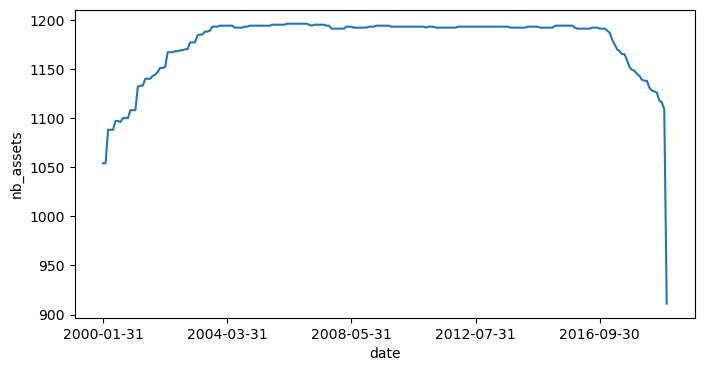

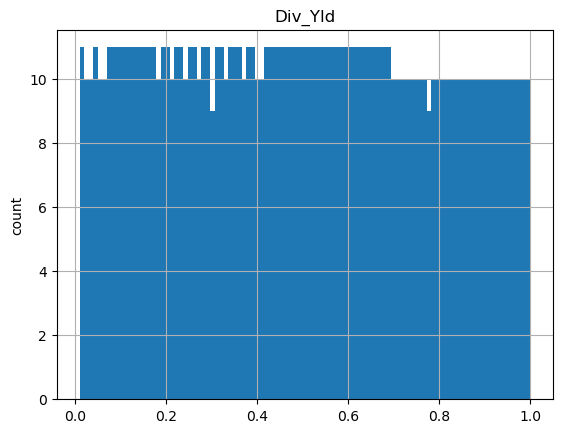

In [1]:
import import_ipynb
from Ch1 import data_ml

In [2]:
from Ch1 import returns

In [3]:
import datetime as dt
from datetime import datetime
import numpy as np
# 백테스트 시작 지점
sep_oos="2007-01-01"
# 모든 자산들의 식별 코드 리스트
ticks=list(data_ml['stock_id'].unique())
# 최대 자산 개수
N=len(ticks)
# 표본 외 날짜 
t_oos=list(returns.index[returns.index>sep_oos].values)
# 전체 날짜
t_as=list(returns.index.values)
# 표본 외 날짜 개수
Tt=len(t_oos)
# 포트폴리오/전략 개수: 머신러닝 기반 & 동일 가중 기반 벤치마크 두 개만 고려
nb_port=2
# 포트폴리오 가중치 초기화
portf_weights=np.zeros(shape=(Tt, nb_port, max(ticks)+1))
# 포트폴리오 수익률 초기화
portf_returns=np.zeros(shape=(Tt, nb_port))

In [4]:
import xgboost as xgb

In [5]:
def weights_xgb(train_data, test_data, features):
    # 독립 변수
    train_features=train_data[features]
    # 종속 변수
    train_label=train_data['R12M_Usd']/np.exp(train_data['Vol1Y_Usd']) # 12개월 미래 수익률
    # 필터
    ind=(train_label<np.quantile(train_label, 0.2))|(train_label>np.quantile(train_label, 0.8))
    # 필터 거친 특성
    train_features=train_features.loc[ind]
    # 필터 거친 레이블
    train_label=train_label.loc[ind]
    # XGB 형태
    train_matrix=xgb.DMatrix(train_features, label=train_label)
    params={'eta':0.3, 'objective':'reg:squarederror', 'max_depth':4}
    # 사용된 트리 개수
    fit_xgb=xgb.train(params, train_matrix, num_boost_round=80)
    # 테스트 샘플 -> XGB 형태
    test_features=test_data[features]
    test_matrix=xgb.DMatrix(test_features)
    pred=fit_xgb.predict(test_matrix)
    w_names=test_data['stock_id']
    w=pred>np.median(pred) # 최적 예측의 50%만 유지
    w=w/np.sum(w)
    return w, w_names


In [6]:
def portf_compo(train_data, test_data, features, j):
    if j==0: # 벤치마크
        N=len(test_data['stock_id'].unique())
        w=np.repeat(1/N,N) # 동일 가중 포트폴리오
        w_names=test_data['stock_id'].unique()
        return w, w_names
    elif j==1: # 머신러닝
        return weights_xgb(train_data, test_data, features)

In [7]:
from Ch1 import features

In [8]:
m_offset=12 # 버퍼 기간 위한 오프셋 개월 수
train_size=5 # 훈련셋 사이즈 연수
for t in range(len(t_oos)-1):
    ind=(data_ml['date']<datetime.strftime(datetime.strptime(t_oos[t],'%Y-%m-%d')-dt.timedelta(m_offset*30), '%Y-%m-%d'))  \
    & (data_ml['date']>datetime.strftime(datetime.strptime(t_oos[t], '%Y-%m-%d')-dt.timedelta(m_offset*30)-dt.timedelta(365*train_size),'%Y-%m-%d'))
    train_data=data_ml.loc[ind,:] # 훈련 샘플
    test_data=data_ml.loc[data_ml['date']==t_oos[t],:]
    # 1개월 홀딩 기간을 고려한 수익률 계산
    realized_returns=test_data["R1M_Usd"]
    # 수익률 계산
    for j in range(nb_port):
        temp_weights, stocks=portf_compo(
            train_data, test_data, features, j
        )
        portf_weights[t,j,stocks]=temp_weights
        portf_returns[t,j]=np.sum(temp_weights*realized_returns)

- 버퍼 기간: 레이블이 장기(12개월) 수익률을 기반으로 하기 때문에 필수적임 ~ 미래 참조 편향 피하기 위함

In [9]:
# 회전율(가중치 변동) 계산하는 함수
def turnover(weights, asset_returns, t_oos):
    turn=0
    for t in range(1,len(t_oos)):
        realised_returns=asset_returns[returns.index==t_oos[t]].values
        prior_weights=weights[t-1]*(1+realised_returns)
        turn=turn+np.sum(np.abs(weights[t]-prior_weights/np.sum(prior_weights)))
    return turn/(len(t_oos)-1)

In [10]:
def perf_met(portf_returns, weights, asset_returns, t_oos):
    # 산술 평균
    avg_ret=np.nanmean(portf_returns)
    # 변동성
    vol=np.nanstd(portf_returns, ddof=1)
    # 샤프 비율
    Sharpe_ratio=avg_ret/vol
    # VaR
    VaR_5=np.quantile(portf_returns, 0.05)
    # turnover 함수 사용
    turn=turnover(weights, asset_returns, t_oos)
    # 모든 지표
    met=[avg_ret, vol, Sharpe_ratio, VaR_5, turn]
    return met

In [11]:
import pandas as pd
# 다양한 전략 반복
def perf_met_multi(portf_returns, weights, asset_returns, t_oos, start_name):
    J=weights.shape[1] # 전략 개수
    met=[]
    for j in range(J):
        temp_met=perf_met(portf_returns[:,j],weights[:,j,:], asset_returns, t_oos)
        met.append(temp_met)
    return pd.DataFrame(met, index=start_name, columns=['avg_ret','vol','Sharpe_ratio','VaR_5','turn'])

In [12]:
asset_returns=data_ml[['date','stock_id','R1M_Usd']].pivot(index='date', columns='stock_id',values='R1M_Usd')
# 누락된 stock_id 찾기
na=list(set(np.arange(max(asset_returns.columns)+1)).difference(set(asset_returns.columns))) # 차집합
asset_returns[na]=0
asset_returns=asset_returns.loc[:, sorted(asset_returns.columns)]
asset_returns.fillna(0, inplace=True) # 결측치에는 0 수익률 할당
perf_met_multi(portf_returns, portf_weights, asset_returns, t_oos, start_name=['EW','XGB_SR'])

,avg_ret,vol,Sharpe_ratio,VaR_5,turn
EW,0.009697,0.056429,0.171848,-0.077125,0.071451
XGB_SR,0.012585,0.063219,0.199066,-0.087143,0.563090


C:\Users\82103\AppData\Local\Temp\ipykernel_20156\401425022.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  g2['benchmark']=g1.loc[g1['date_month']==12,'benchmark']
C:\Users\82103\AppData\Local\Temp\ipykernel_20156\401425022.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  g2[['benchmark','ml_based']].pct_change(1).plot.bar(figsize=[16,6],ylabel='Yearly performance')


<Axes: xlabel='date', ylabel='Yearly performance'>

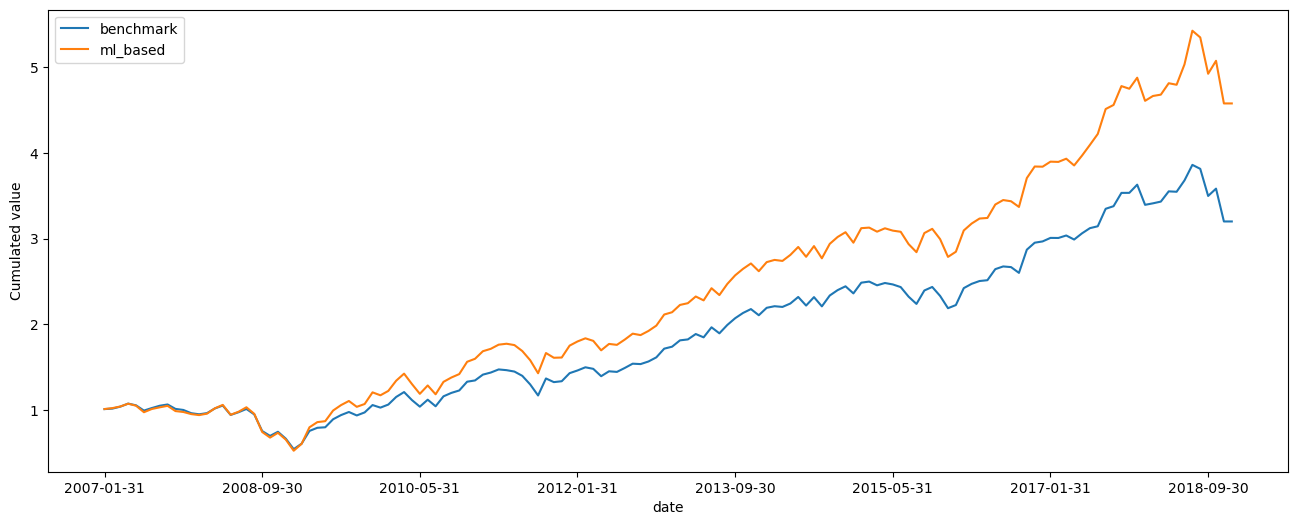

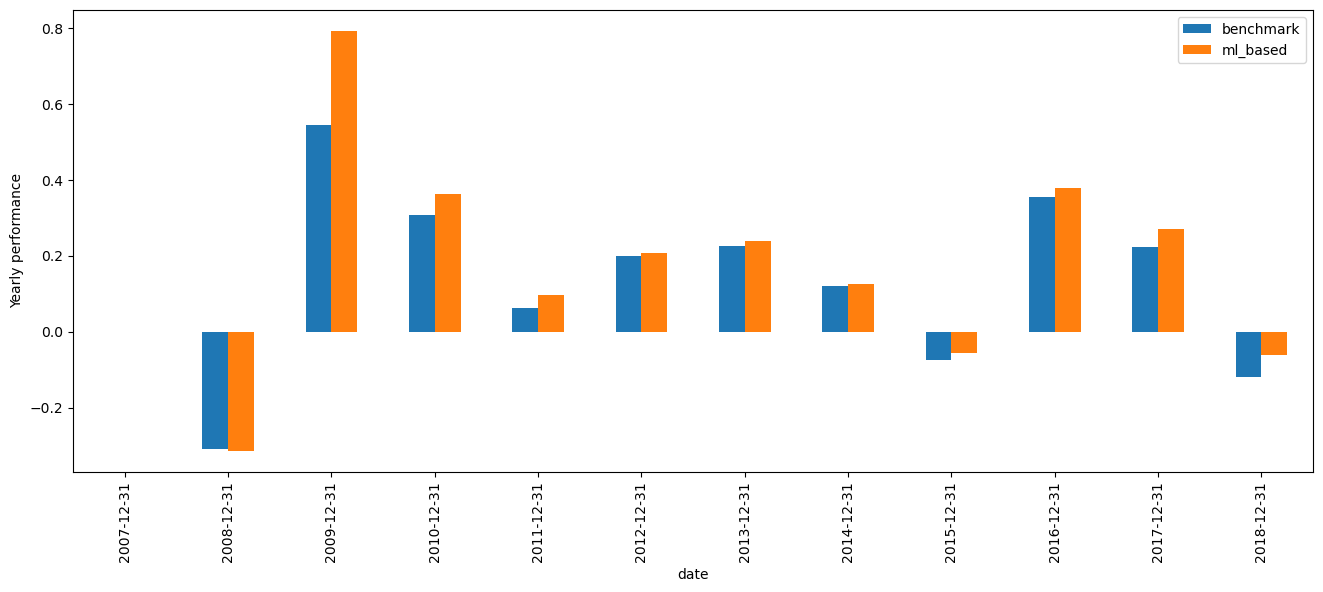

In [15]:
g1=pd.DataFrame([t_oos, np.cumprod(1+portf_returns[:,0]), np.cumprod(1+portf_returns[:,1])], index=['date','benchmark','ml_based']).T
g1.reset_index(inplace=True)
g1['date_month']=pd.to_datetime(g1['date']).dt.month
g1.set_index('date', inplace=True)
g2=g1[g1['date_month']==12]
g2['benchmark']=g1.loc[g1['date_month']==12,'benchmark']
g2.sort_index(inplace=True)
g1[['benchmark','ml_based']].plot(figsize=[16,6], ylabel='Cumulated value')
g2[['benchmark','ml_based']].pct_change(1).plot.bar(figsize=[16,6],ylabel='Yearly performance')

[12.7] 2nd: 백테스트 과최적화

In [17]:
# 성과지표 생성함수: 선택한 특성, 임계치 수준, 방향 -> 3가지 입력에 따라 달라짐
def strat(data, feature, thresh, direction):
    # 개별 특성에 대한 데이터
    data_tmp=data[[feature, 'date','R1M_Usd']].copy()
    # 투자 의사결정 with 불리언 값
    data_tmp['decision']=direction*data_tmp[feature]>direction*thresh
    # 일별 분석
    data_tmp=data_tmp.groupby('date').apply(
        lambda x: np.sum(x['decision']/np.sum(x['decision'])*x['R1M_Usd'])
    )
    avg=np.nanmean(data_tmp)
    sd=np.nanstd(data_tmp,ddof=1)
    SR=avg/sd
    return np.around([avg, sd, SR], 4)

In [18]:
strat(data_ml, 'Pb', 0.3, 1)
# 포지션: 양수, 전략이 분포의 0.3 사분위수보다 높은 Pb 값을 가진 주식 매수

C:\Users\82103\AppData\Local\Temp\ipykernel_20156\3074808913.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_tmp=data_tmp.groupby('date').apply(


array([0.0102, 0.0496, 0.2065])

In [19]:
import itertools
feature=['Div_Yld','Ebit_Bv','Mkt_Cap_6M_Usd','Mom_11M_Usd','Pb','Vol1Y_Usd']
thresh=np.arange(0.2,0.9,0.1)
direction=np.array([-1,1])

C:\Users\82103\AppData\Local\Temp\ipykernel_20156\3074808913.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_tmp=data_tmp.groupby('date').apply(
C:\Users\82103\AppData\Local\Temp\ipykernel_20156\3074808913.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_tmp=data_tmp.groupby('date').apply(
C:\Users\82103\AppData\Local\Temp\ipykernel_20156\3074808913.py:8: FutureWarning: DataFrameGroupBy.apply operate

<Axes: xlabel='thresh', ylabel='Direction=1'>

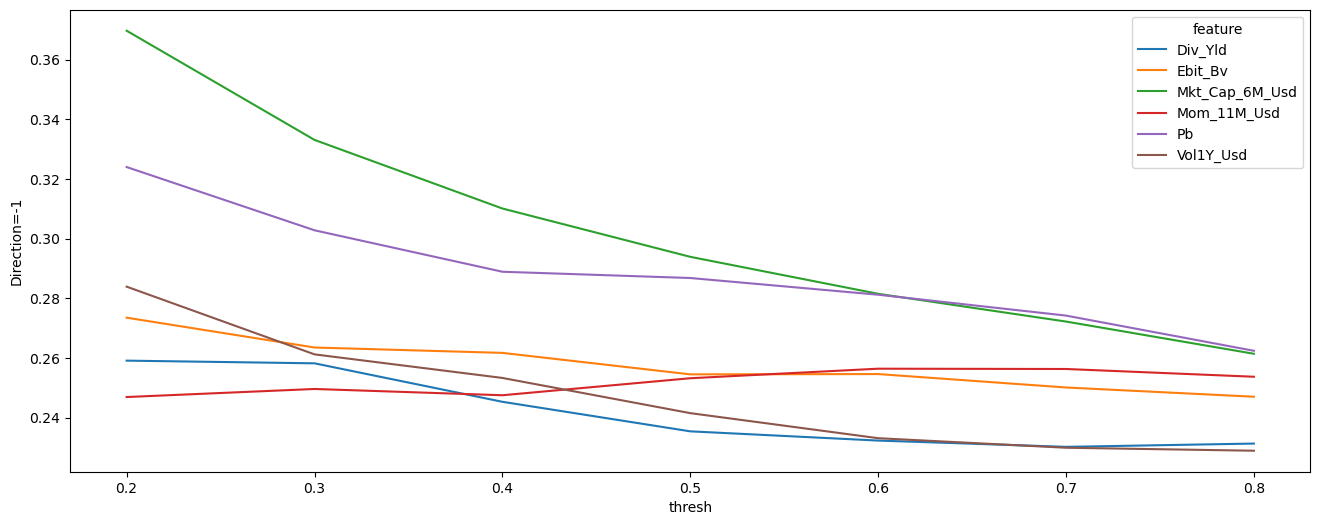

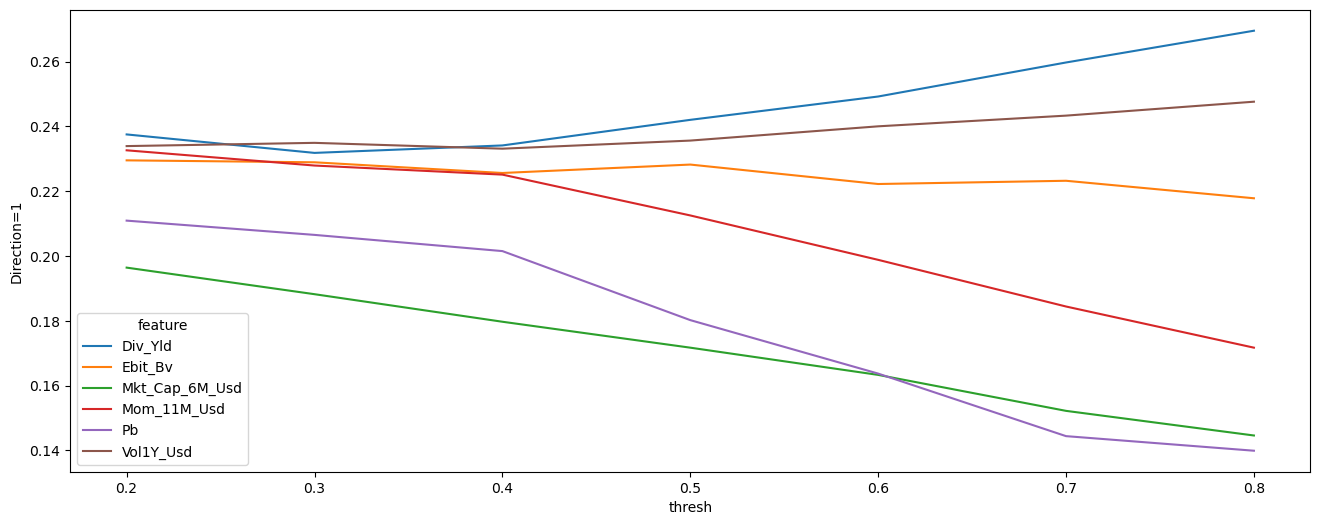

In [20]:
grd=[] # 격자 탐색 위한 매개변수
for f,t,d in itertools.product(feature, thresh, direction):
    strat_data=[]
    strat_data=pd.DataFrame(strat(data_ml, f, t, d)).T
    strat_data.rename(columns={0:'avg',1:'sd',2:'SR'}, inplace=True)
    strat_data[['feature','thresh','direction']]=f,t,d
    grd.append(strat_data)
grd=pd.concat(grd)[['feature','thresh','direction','avg','sd','SR']]
grd[grd['direction']==-1].pivot(index='thresh',columns='feature',values='SR').plot(figsize=[16,6], ylabel='Direction=-1')
grd[grd['direction']==1].pivot(index='thresh',columns='feature',values='SR').plot(figsize=[16,6], ylabel='Direction=1')

In [21]:
from scipy import special as special
from scipy import stats as stats

def DSR(SR, Tt, M, g3, g4, SR_m, SR_v):
    gamma=-special.digamma(1)
    SR_star=SR_m+np.sqrt(SR_v)*((1-gamma)*stats.norm.ppf(1-1/M)+gamma*stats.norm.ppf(1-1/M/np.exp(1)))
    num=(SR-SR_star)*np.sqrt(Tt-1)
    den=np.sqrt(1-g3*SR+(g4-1)/4*SR**2)
    return round(stats.norm.cdf(num/den),4)

In [22]:
M=grd.shape[0] # 검증할 전략 개수
SR=np.max(grd['SR']) # 검증하고자 하는 샤프 비율
SR_m=np.mean(grd['SR'])
SR_v=np.var(grd['SR'], ddof=1)
data_tmp=data_ml[['Mkt_Cap_6M_Usd','date','R1M_Usd']].copy()
data_tmp.rename({'Mkt_Cap_6M_Usd':'feature'},axis=1,inplace=True)
data_tmp['decision']=data_tmp['feature']<0.2
returns_DSR=data_tmp.groupby('date').apply(
    lambda x: np.sum(x['decision']/np.sum(x['decision'])*x['R1M_Usd'])
)
g3=stats.skew(returns_DSR)
g4=stats.kurtosis(returns_DSR, fisher=False)
Tt=returns_DSR.shape[0]
DSR(SR, Tt, M, g3, g4, SR_m, SR_v)

C:\Users\82103\AppData\Local\Temp\ipykernel_20156\64504797.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  returns_DSR=data_tmp.groupby('date').apply(


np.float64(0.6657)